# 01 - Exploracion de Datos Historicos en Supabase

Este notebook conecta con Supabase para verificar los datos historicos del sensor BME680.

## 1. Instalacion de dependencias

In [1]:
import sys
!{sys.executable} -m pip install -q supabase pandas python-dotenv

## 2. Configuracion de conexion

In [2]:
from supabase import create_client
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Conexion a Supabase establecida")
print(f"URL: {SUPABASE_URL}")

Conexion a Supabase establecida
URL: https://ffwjdoguzaqpafuwaeam.supabase.co


## 3. Verificacion de estructura de tabla

In [3]:
response = supabase.table("grupo1_air_quality").select("*").limit(1).execute()

if response.data:
    print("Columnas disponibles:")
    for key in response.data[0].keys():
        print(f"  - {key}")
else:
    print("No se encontraron datos en la tabla")

Columnas disponibles:
  - id
  - estacion
  - temperatura
  - humedad
  - presion
  - altura
  - gas
  - iaq
  - eco2
  - voc
  - calidad_aire
  - created_at


## 4. Carga de datos historicos

In [4]:
response = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(100).execute()

df = pd.DataFrame(response.data)
print(f"Total registros cargados: {len(df)}")
df.head(10)

Total registros cargados: 100


,id,estacion,temperatura,humedad,presion,altura,gas,iaq,eco2,voc,calidad_aire,created_at
0,4429,grupo1,9.704172,21.10805,647.68,3619.001,28828,69.45975,1039.030,3.903528,Buena,2026-06-23T08:32:53.117839-05:00
1,4428,grupo1,9.704806,21.40956,647.69,3618.881,28207,67.95222,1025.161,3.829659,Buena,2026-06-23T08:31:53.105134-05:00
2,4427,grupo1,9.688326,21.10719,647.68,3619.001,28188,69.46407,1039.069,3.903739,Buena,2026-06-23T08:30:53.194604-05:00
3,4426,grupo1,9.673429,21.00437,647.67,3619.121,28284,69.97815,1043.799,3.928929,Buena,2026-06-23T08:29:53.101937-05:00
4,4425,grupo1,9.668993,20.88694,647.68,3619.001,27981,70.56532,1049.201,3.957701,Buena,2026-06-23T08:28:53.132864-05:00
5,4424,grupo1,9.673746,21.02988,647.68,3619.001,27236,69.85061,1042.626,3.922680,Buena,2026-06-23T08:27:53.109527-05:00
6,4423,grupo1,9.671844,21.09608,647.69,3618.881,26715,69.51958,1039.580,3.906459,Buena,2026-06-23T08:26:53.154751-05:00
7,4422,grupo1,9.676916,20.95359,647.69,3618.881,26462,70.23205,1046.135,3.941370,Buena,2026-06-23T08:25:53.093411-05:00
8,4421,grupo1,9.689276,20.73025,647.70,3618.761,26329,71.34873,1056.408,3.996088,Buena,2026-06-23T08:24:53.158866-05:00
9,4420,grupo1,9.669310,20.84112,647.69,3618.881,25890,70.79438,1051.308,3.968925,Buena,2026-06-23T08:23:53.402041-05:00


## 5. Estadisticas descriptivas

In [5]:
numeric_possible = ["temperatura", "humedad", "presion", "iaq", "eco2", "voc", "VOC", "gas", "altura"]
numeric_cols = [c for c in numeric_possible if c in df.columns]

print(f"Columnas numericas encontradas: {numeric_cols}")
if numeric_cols:
    df[numeric_cols].describe()
else:
    print("No se encontraron columnas numericas conocidas")

Columnas numericas encontradas: ['temperatura', 'humedad', 'presion', 'iaq', 'eco2', 'voc', 'gas', 'altura']


## 6. Distribucion de calidad del aire

In [6]:
if "calidad_aire" in df.columns:
    print("Distribucion de calidad_aire:")
    print(df["calidad_aire"].value_counts())
else:
    print("Columna calidad_aire no encontrada")

Distribucion de calidad_aire:
calidad_aire
Buena    100
Name: count, dtype: int64


## 7. Rango temporal de los datos

In [7]:
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"])
    print(f"Primer registro: {df['created_at'].min()}")
    print(f"Ultimo registro: {df['created_at'].max()}")
    print(f"Rango: {df['created_at'].max() - df['created_at'].min()}")

Primer registro: 2026-06-23 06:51:53.869027-05:00
Ultimo registro: 2026-06-23 08:32:53.117839-05:00
Rango: 0 days 01:40:59.248812


## 8. Visualizacion rapida de temperatura

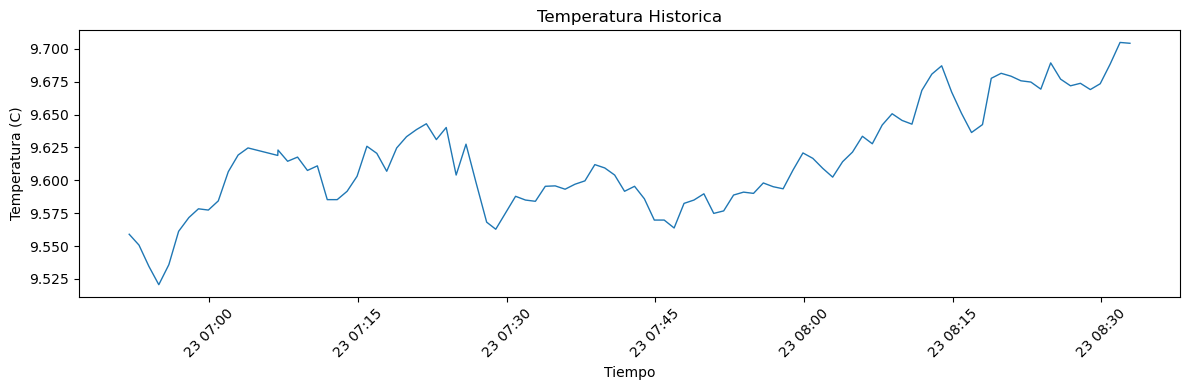

In [8]:
import matplotlib.pyplot as plt

if "created_at" in df.columns and "temperatura" in df.columns:
    df_sorted = df.sort_values("created_at")
    plt.figure(figsize=(12, 4))
    plt.plot(df_sorted["created_at"], df_sorted["temperatura"], linewidth=1)
    plt.title("Temperatura Historica")
    plt.xlabel("Tiempo")
    plt.ylabel("Temperatura (C)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Dato mas reciente (polling opcional)

Esta celda hace polling a Supabase para ver el ultimo registro. No es streaming real, solo verificacion puntual.

In [9]:
import time

print("Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...\n")
try:
    for i in range(6):
        resp = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(1).execute()
        if resp.data:
            d = resp.data[0]
            print(f"[{i+1}] {d.get('created_at')} | Temp: {d.get('temperatura')}C | Hum: {d.get('humedad')}% | IAQ: {d.get('iaq')}")
        time.sleep(5)
except KeyboardInterrupt:
    print("\nPolling detenido")

Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...

[1] 2026-06-23T08:32:53.117839-05:00 | Temp: 9.704172C | Hum: 21.10805% | IAQ: 69.45975
[2] 2026-06-23T08:32:53.117839-05:00 | Temp: 9.704172C | Hum: 21.10805% | IAQ: 69.45975
[3] 2026-06-23T08:32:53.117839-05:00 | Temp: 9.704172C | Hum: 21.10805% | IAQ: 69.45975
[4] 2026-06-23T08:32:53.117839-05:00 | Temp: 9.704172C | Hum: 21.10805% | IAQ: 69.45975
[5] 2026-06-23T08:32:53.117839-05:00 | Temp: 9.704172C | Hum: 21.10805% | IAQ: 69.45975
[6] 2026-06-23T08:32:53.117839-05:00 | Temp: 9.704172C | Hum: 21.10805% | IAQ: 69.45975
